# 01 — Esplorazione Keypoints CSV

Questo notebook serve per esplorare il CSV grezzo dei keypoint estratti da YOLO-Pose.
Eseguilo dopo aver ricevuto il primo CSV dal Membro A.

**Obiettivi:**
- Verificare che il formato CSV sia corretto
- Visualizzare la distribuzione dei NaN
- Plottare la velocità del polso su un clip di prova
- Confermare che lo scheletro viene disegnato correttamente

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yaml

# Carica la configurazione
with open('../config.yaml') as f:
    config = yaml.safe_load(f)

print('Config caricato:', list(config.keys()))

Config caricato: ['yolo', 'keypoints', 'preprocessing', 'detection', 'classification', 'statistics', 'render']


In [2]:
# ── Carica il CSV grezzo ──────────────────────────────────────────────
CSV_PATH = '../data/keypoints/clip1.csv'   # <-- cambia con il tuo file

df = pd.read_csv(CSV_PATH)
print(f'Shape: {df.shape}')
print(f'Colonne: {list(df.columns[:10])} ... ({len(df.columns)} totali)')
df.head(3)

Shape: (900, 58)
Colonne: ['frame', 'time_s', 'track_id', 'bbox_x1', 'bbox_y1', 'bbox_x2', 'bbox_y2', 'kp0_x', 'kp0_y', 'kp0_conf'] ... (58 totali)


,frame,time_s,track_id,bbox_x1,bbox_y1,bbox_x2,bbox_y2,kp0_x,kp0_y,kp0_conf,...,kp13_conf,kp14_x,kp14_y,kp14_conf,kp15_x,kp15_y,kp15_conf,kp16_x,kp16_y,kp16_conf
0,0,0.0000,1,687.3,319.2,962.8,977.0,873.6093,379.2032,0.0680,...,0.9989,868.7673,778.6818,0.9989,720.9549,913.5961,0.9895,865.4577,930.0867,0.9893
1,1,0.0333,1,687.2,319.2,962.6,977.0,873.6149,379.2628,0.0681,...,0.9989,868.8475,778.6128,0.9989,720.8986,913.6979,0.9895,865.5215,929.9469,0.9892
2,2,0.0667,1,681.3,318.1,961.0,975.9,871.9823,379.0620,0.0593,...,0.9989,866.4911,777.3940,0.9989,714.0717,910.5507,0.9889,865.2469,929.1302,0.9893


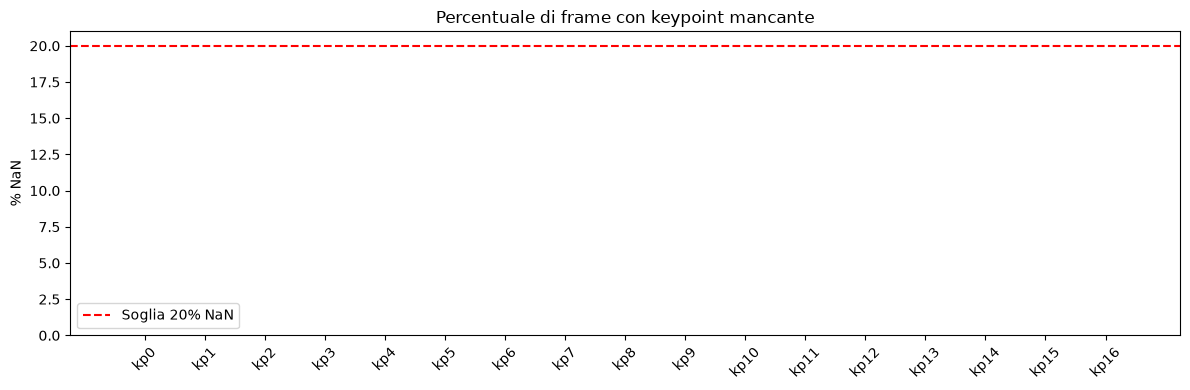

In [3]:
# ── Percentuale NaN per keypoint ─────────────────────────────────────
nan_pct = {}
for i in range(17):
    col = f'kp{i}_x'
    if col in df.columns:
        nan_pct[f'kp{i}'] = df[col].isna().mean() * 100

plt.figure(figsize=(12, 4))
plt.bar(nan_pct.keys(), nan_pct.values(), color='steelblue')
plt.axhline(20, color='red', linestyle='--', label='Soglia 20% NaN')
plt.ylabel('% NaN')
plt.title('Percentuale di frame con keypoint mancante')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

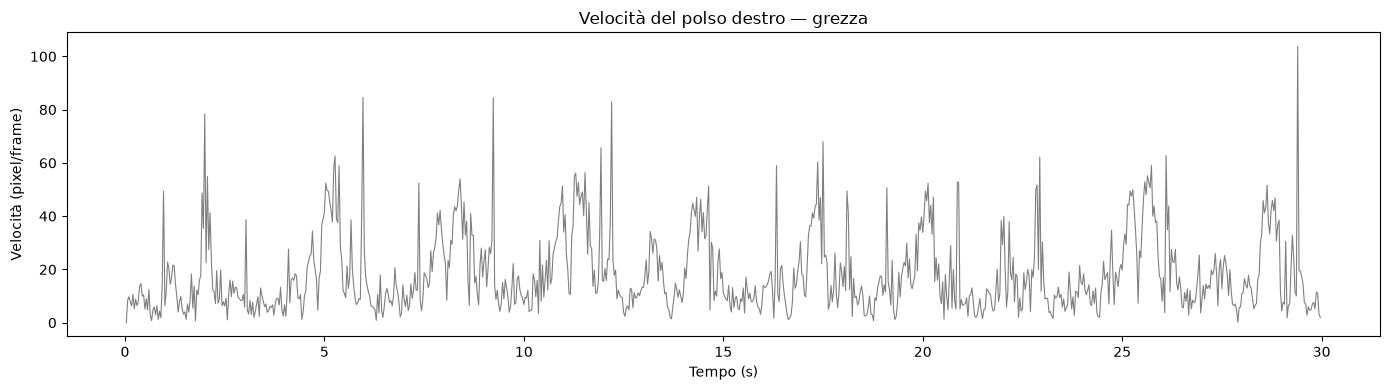

Velocità media: 18.3353
Velocità max:   103.8304


In [4]:
# ── Velocità del polso destro (kp10) ─────────────────────────────────
vx = df['kp10_x'].diff()
vy = df['kp10_y'].diff()
speed = np.sqrt(vx**2 + vy**2)

plt.figure(figsize=(14, 4))
plt.plot(df['time_s'], speed, color='gray', linewidth=0.8)
plt.xlabel('Tempo (s)')
plt.ylabel('Velocità (pixel/frame)')
plt.title('Velocità del polso destro — grezza')
plt.tight_layout()
plt.show()

print(f'Velocità media: {speed.mean():.4f}')
print(f'Velocità max:   {speed.max():.4f}')

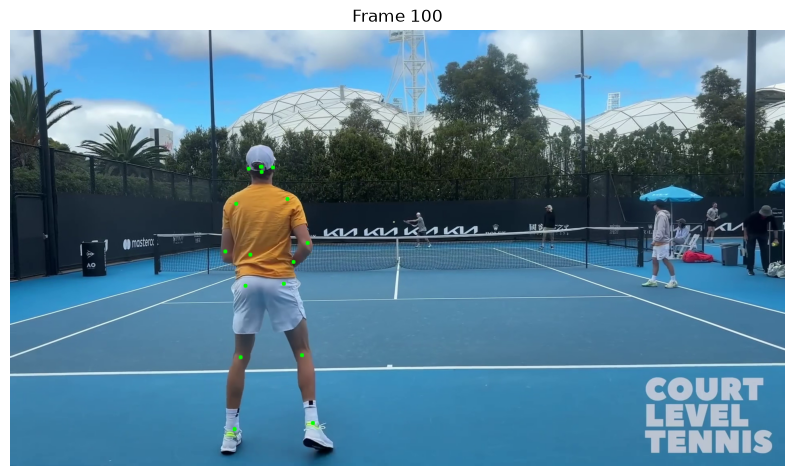

In [5]:
# ── Visualizza lo scheletro su un singolo frame ───────────────────────
import cv2

VIDEO_PATH = '../data/raw/sinner_30s.mov'  # <-- cambia con il tuo file
FRAME_TO_SHOW = 100

cap = cv2.VideoCapture(VIDEO_PATH)
cap.set(cv2.CAP_PROP_POS_FRAMES, FRAME_TO_SHOW)
ret, frame = cap.read()
cap.release()

if ret:
    row = df[df['frame'] == FRAME_TO_SHOW]
    if len(row) > 0:
        r = row.iloc[0]
        for i in range(17):
            x = r.get(f'kp{i}_x', np.nan)
            y = r.get(f'kp{i}_y', np.nan)
            if not np.isnan(x):
                cv2.circle(frame, (int(x), int(y)), 5, (0, 255, 0), -1)

    plt.figure(figsize=(10, 6))
    plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))  # OpenCV usa BGR, matplotlib RGB
    plt.title(f'Frame {FRAME_TO_SHOW}')
    plt.axis('off')
    plt.show()
else:
    print('Video non trovato — controlla il percorso.')